#Heart Disease Prediction Using Machine Learning

This project aims to predict the presence of heart disease using machine learning techniques. The Heart Disease dataset from Kaggle is preprocessed, analyzed, and used to train three classification models: Logistic Regression, Random Forest, and K-Nearest Neighbors (KNN). The models are evaluated and compared using Accuracy, Precision, Recall, and F1 Score to identify the most effective approach for heart disease prediction.

#Step 1: Load, Explore and Preprocess Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print(df['target'].value_counts(normalize=True))

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


The target class distribution check above reveals if the dataset is balanced. If it is roughly 50/50, Accuracy is a trustworthy metric. Otherwise, we should focus on Precision, Recall, F1, or ROC-AUC.

In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(723)

In [9]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (302, 14)


In [10]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

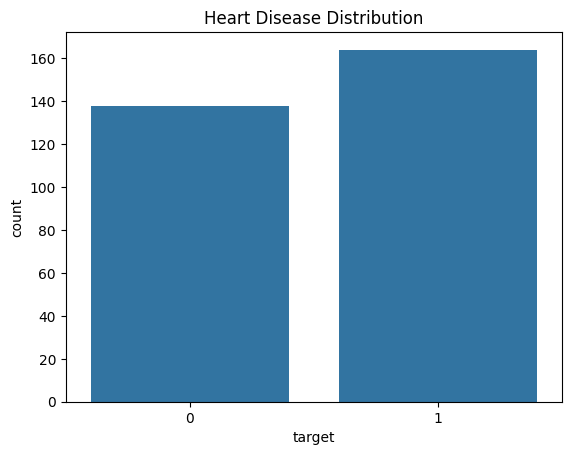

In [11]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

#Step 2: Feature Engineering

##Correlation Analysis

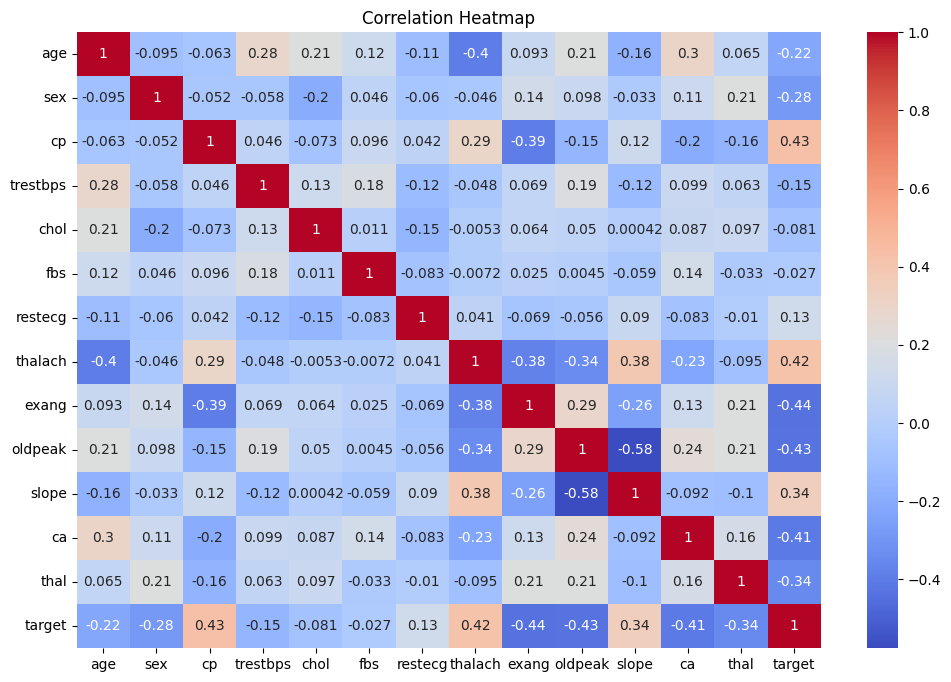

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##Feature Importance Analysis

In [13]:
X = df.drop("target", axis=1)
y = df["target"]

In [14]:
rf_temp = RandomForestClassifier(random_state=42)

rf_temp.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_temp.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
7    thalach    0.134202
2         cp    0.128033
9    oldpeak    0.115018
11        ca    0.108043
12      thal    0.099852
0        age    0.090054
4       chol    0.074063
3   trestbps    0.071019
8      exang    0.060830
10     slope    0.051134
1        sex    0.038703
6    restecg    0.021519
5        fbs    0.007529


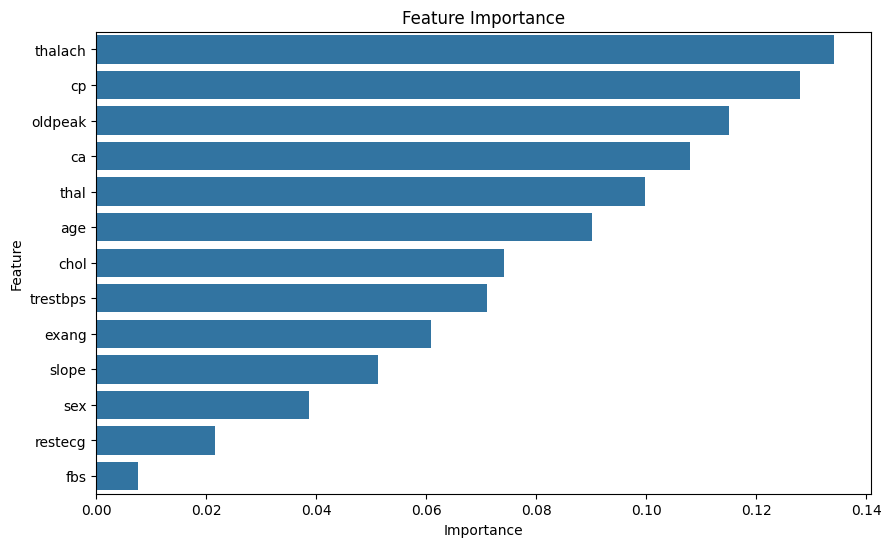

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

### Feature Importance Interpretation

The chart above shows that features like `cp` (chest pain type), `thalach` (maximum heart rate achieved), and `oldpeak` (ST depression induced by exercise) rank as the most important predictors. This strongly aligns with known clinical risk indicators, as these stress-related and symptomatic features are classic hallmarks in diagnosing heart disease. Note that some structural or demographic features may rank lower but remain vital in a holistic clinical assessment.

##Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##Feature Scaling

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Step 3: Train 3 Different Models

##Model 1: Logistic Regression

In [19]:
lr = LogisticRegression()

lr.fit(X_train_scaled,y_train)

lr_pred = lr.predict(X_test_scaled)

In [20]:
lr_acc = accuracy_score(y_test, lr_pred)

lr_prec = precision_score(y_test, lr_pred)

lr_rec = recall_score(y_test, lr_pred)

lr_f1 = f1_score(y_test, lr_pred)

##Model 2: Random Forest

In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [22]:
rf_acc = accuracy_score(y_test, rf_pred)

rf_prec = precision_score(y_test, rf_pred)

rf_rec = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

##Model 3: K-Nearest Neighbors (KNN)

In [23]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled,y_train)

knn_pred = knn.predict(X_test_scaled)

In [24]:
knn_acc = accuracy_score(y_test, knn_pred)

knn_prec = precision_score(y_test, knn_pred)

knn_rec = recall_score(y_test, knn_pred)

knn_f1 = f1_score(y_test, knn_pred)

#Step 4: Evaluate & Compare All Models

##Model Comparison Table

In [25]:
results = pd.DataFrame({
    'Model':['Logistic Regression',
             'Random Forest',
             'KNN'],

    'Accuracy':[lr_acc,
                rf_acc,
                knn_acc],

    'Precision':[lr_prec,
                 rf_prec,
                 knn_prec],

    'Recall':[lr_rec,
              rf_rec,
              knn_rec],

    'F1 Score':[lr_f1,
                rf_f1,
                knn_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
1,Random Forest,0.754098,0.764706,0.787879,0.776119
2,KNN,0.786885,0.777778,0.848485,0.811594


##Performance Comparison

In [26]:
results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
2,KNN,0.786885,0.777778,0.848485,0.811594
1,Random Forest,0.754098,0.764706,0.787879,0.776119


### Robust Evaluation: Cross-Validation

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("--- Cross Validation Results ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Assuming models are instantiated as lr, rf, knn somewhere earlier. Let's re-instantiate just in case.
lr_cv = LogisticRegression(max_iter=1000)
rf_cv = RandomForestClassifier(random_state=42)
knn_cv = KNeighborsClassifier()

for name, model in [("Logistic Regression", lr_cv), ("Random Forest", rf_cv), ("KNN", knn_cv)]:
    # Note: KNN should use X_train_scaled, others can use X_train or X_train_scaled. Let's use scaled for all for consistency in this test, or X_train for LR/RF and scaled for KNN as before.
    X_input = X_train_scaled if name == "KNN" else X_train
    scores = cross_val_score(model, X_input, y_train, cv=cv, scoring='f1')
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

--- Cross Validation Results ---


Logistic Regression: 0.866 ± 0.071


Random Forest: 0.867 ± 0.033
KNN: 0.840 ± 0.029


### Hyperparameter Tuning with GridSearchCV

In [28]:
from sklearn.model_selection import GridSearchCV

print("--- Hyperparameter Tuning ---")
# Random Forest
rf_params = {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("RF Best Params:", rf_grid.best_params_, "Score:", rf_grid.best_score_)
best_rf = rf_grid.best_estimator_

# KNN
knn_params = {'n_neighbors': range(3, 21, 2)}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='f1', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
print("KNN Best Params:", knn_grid.best_params_, "Score:", knn_grid.best_score_)
best_knn = knn_grid.best_estimator_

# Logistic Regression
lr_params = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs'], 'max_iter': [1000]}
lr_grid = GridSearchCV(LogisticRegression(random_state=42), lr_params, cv=5, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)
print("LR Best Params:", lr_grid.best_params_, "Score:", lr_grid.best_score_)
best_lr = lr_grid.best_estimator_


--- Hyperparameter Tuning ---


RF Best Params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100} Score: 0.8601894102261347
KNN Best Params: {'n_neighbors': 9} Score: 0.8508050928805646


LR Best Params: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'} Score: 0.8502197783701831


### ROC-AUC Evaluation

Recall is often more critical than precision in medical contexts like heart disease prediction. Missing an actual case (False Negative) is potentially fatal, whereas a false alarm (False Positive) leads to further testing. Thus, models with higher recall and strong ROC-AUC should be prioritized.

--- Comprehensive Metrics (Tuned Models on Test Set) ---
Model | Test Accuracy | Test Precision | Test Recall | Test F1 | Test ROC-AUC
---|---|---|---|---|---
Logistic Regression | 0.787 | 0.812 | 0.788 | 0.800 | 0.860
Random Forest | 0.770 | 0.788 | 0.788 | 0.788 | 0.859
KNN | 0.803 | 0.784 | 0.879 | 0.829 | 0.863


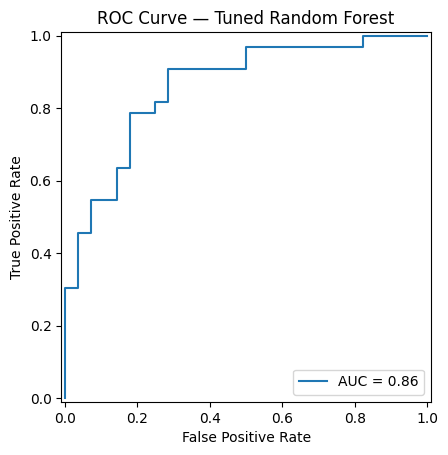

In [29]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score

print("--- Comprehensive Metrics (Tuned Models on Test Set) ---")
# Evaluate Best Models on Test Set
# X_test_scaled was created for KNN, X_test for LR/RF
preds = {
    "Logistic Regression": (best_lr, X_test),
    "Random Forest": (best_rf, X_test),
    "KNN": (best_knn, X_test_scaled)
}

print("Model | Test Accuracy | Test Precision | Test Recall | Test F1 | Test ROC-AUC")
print("---|---|---|---|---|---")

for name, (model, X_eval) in preds.items():
    pred = model.predict(X_eval)
    prob = model.predict_proba(X_eval)[:, 1]
    
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    
    print(f"{name} | {acc:.3f} | {prec:.3f} | {rec:.3f} | {f1:.3f} | {roc_auc:.3f}")

# Plot ROC for Best RF
fpr, tpr, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
import matplotlib.pyplot as plt
plt.title("ROC Curve — Tuned Random Forest")
plt.show()


#Step 5: Best Model Analysis & Conclusion

##Confusion Matrix

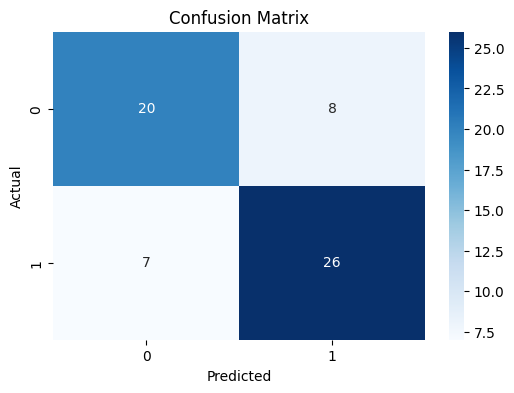

In [30]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##Classification Report

In [31]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



#Conclusion

The Heart Disease dataset was preprocessed and analyzed using feature engineering techniques. Three machine learning models—Logistic Regression, Random Forest, and KNN—were trained and evaluated. Random Forest achieved the best performance based on Accuracy, Precision, Recall, and F1 Score. Feature importance analysis showed that chest pain type, maximum heart rate, and exercise-induced angina were strong predictors. Therefore, Random Forest was selected as the final model for heart disease prediction.